# 03 - Custom CNN (Trained From Scratch)

**Owner:** Member 1
**Role in the study:** from-scratch baseline. Shows what a CNN can learn from this dataset *without* ImageNet pretraining, so the benefit of transfer learning (MobileNetV2, ResNet50, EfficientNetB0) can be quantified.

## Objective
1. Build a compact convolutional network trained from randomly initialised weights.
2. Select the architecture/regularisation using **training + validation data only** (3 controlled experiments).
3. Evaluate the frozen configuration **once** on the untouched test set.
4. Record everything needed for the four-model comparison: metrics, curves, confusion matrix, error analysis, parameters, training time, hardware, model size, inference latency and run-to-run stability.

## Fair-comparison protocol (aligned with `02_Preprocessing.ipynb` / `results/mobilenetv2_preprocessing_config.json`)
| Setting | Value |
|---|---|
| Splits | Kaggle-provided `Train` (1,322) / `Validation` (60) / `Test` (150) folders, unchanged |
| Input size | 224 × 224 RGB (bilinear resize, `image_dataset_from_directory`) |
| Batch size | 32 |
| Seed | 42 (plus 123 and 2026 for the stability study) |
| Augmentation (train only) | RandomFlip(horizontal), RandomRotation(0.05), RandomTranslation(0.05, 0.05), RandomZoom(0.10) — identical to Member 2 |
| Model-specific preprocessing | `Rescaling(1/255)` inside the model (no ImageNet statistics, because no ImageNet weights are used) |
| Loss / metrics | Sparse categorical cross-entropy; accuracy, weighted precision/recall/F1, weighted one-vs-rest ROC-AUC, confusion matrix |

## Run history (transparency note)
This is **Run 2** of this notebook. Run 1 used `MAX_EPOCHS=30`, `EarlyStopping(patience=6)` and `ReduceLROnPlateau(patience=3)`. Its outputs are kept in `results/customcnn_run1_archive/`.

**Why Run 1 was rejected** (diagnosed from training and validation curves):
* **CNN-EXP-01 stopped at epoch 12 while still underfitting.** Training accuracy was only 0.71 at the restored epoch, and training loss was still falling.
* **Both BatchNorm models (EXP-02 and EXP-03) stopped at epoch 7, with epoch 1 as their "best" epoch.** Validation loss on 60 images fluctuates strongly in early epochs, before the BatchNorm moving statistics settle, so a patience of 6 ended training before learning had stabilised.
* **Repeating the selected configuration with different seeds gave very different stopping epochs (6, 11, 16).** This confirmed that the stopping rule, not the architecture, was driving the outcome.

**Change for Run 2:** a longer budget (40 epochs) and more patient callbacks (EarlyStopping patience 10, ReduceLROnPlateau patience 4). This is the standard remedy when training a network from scratch, which converges more slowly than fine-tuning a pretrained head. Architectures, data, augmentation and the selection rule are unchanged.

**Integrity note:** Run 1's test metrics were computed by the notebook automatically, but they were **not** used to make this change. The justification above relies only on training and validation evidence. Both runs are reported in the report so the reader can judge.

## 1. Imports, reproducibility and environment

In [1]:
import os, json, time, platform, random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize

SEED = 42
tf.keras.utils.set_random_seed(SEED)   # seeds python, numpy and tensorflow

DATASET_DIR = Path("../dataset")
TRAIN_DIR, VALIDATION_DIR, TEST_DIR = (DATASET_DIR / s for s in ("Train", "Validation", "Test"))
RESULTS_DIR = Path("../results"); RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR = Path("../models"); MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["Healthy", "Powdery", "Rust"]
NUM_CLASSES = len(CLASS_NAMES)

MAX_EPOCHS = int(os.environ.get("CNN_MAX_EPOCHS", 40))  # env override only used for smoke tests
EARLY_STOP_PATIENCE = 10
LR_PATIENCE = 4
INITIAL_LR = 1e-3

ENVIRONMENT = {
    "tensorflow": tf.__version__,
    "python": platform.python_version(),
    "os": f"{platform.system()} {platform.release()}",
    "processor": platform.processor(),
    "logical_cpus": os.cpu_count(),
    "gpu_used": bool(tf.config.list_physical_devices("GPU")),
}
ENVIRONMENT

{'tensorflow': '2.20.0',
 'python': '3.12.10',
 'os': 'Windows 11',
 'processor': 'AMD64 Family 25 Model 68 Stepping 1, AuthenticAMD',
 'logical_cpus': 16,
 'gpu_used': False}

## 2. Load the three splits
Images are decoded and resized **once** and cached in memory (`.cache()`); this gives exactly the same tensors as re-decoding every epoch but makes CPU training practical (the originals are ~4000×2700 JPEGs). Shuffling happens *after* the cache so every epoch sees a new order. The test set is loaded here but not used until Section 8.

In [2]:
def load_split(directory):
    return tf.keras.utils.image_dataset_from_directory(
        directory, labels="inferred", label_mode="int", class_names=CLASS_NAMES,
        image_size=IMG_SIZE, batch_size=None, shuffle=False)

train_raw = load_split(TRAIN_DIR)
val_raw = load_split(VALIDATION_DIR)
test_raw = load_split(TEST_DIR)
test_file_paths = [Path(p) for p in test_raw.file_paths]

train_raw, val_raw, test_raw = train_raw.cache(), val_raw.cache(), test_raw.cache()
for name, ds in [("train", train_raw), ("validation", val_raw), ("test", test_raw)]:
    labels = np.array([int(y) for _, y in ds])
    print(f"{name:10s} n={len(labels):4d}  per class={np.bincount(labels, minlength=NUM_CLASSES).tolist()}")

Found 1322 files belonging to 3 classes.


Found 60 files belonging to 3 classes.


Found 150 files belonging to 3 classes.


train      n=1322  per class=[458, 430, 434]


validation n=  60  per class=[20, 20, 20]


test       n= 150  per class=[50, 50, 50]


## 3. Augmentation (identical to Member 2) and input pipelines

In [3]:
def make_augmentation(seed):
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip(mode="horizontal", seed=seed),
        tf.keras.layers.RandomRotation(factor=0.05, seed=seed),
        tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05, seed=seed),
        tf.keras.layers.RandomZoom(height_factor=0.10, width_factor=0.10, seed=seed),
    ], name="data_augmentation")

def make_train_pipeline(seed):
    augmentation = make_augmentation(seed)
    return (train_raw.shuffle(len(train_raw), seed=seed, reshuffle_each_iteration=True)
            .batch(BATCH_SIZE)
            .map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

def make_eval_pipeline(ds):
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_pipeline = make_eval_pipeline(val_raw)
train_eval_pipeline = make_eval_pipeline(train_raw)   # un-augmented train set, used to measure the generalisation gap
test_pipeline = make_eval_pipeline(test_raw)

x, y = next(iter(make_train_pipeline(SEED)))
print("Train batch:", x.shape, x.dtype, "pixel range", float(tf.reduce_min(x)), "-", float(tf.reduce_max(x)))

Train batch: (32, 224, 224, 3) <dtype: 'float32'> pixel range 0.11651837080717087 - 255.0


## 4. Custom CNN architecture
Stacked **Conv(3×3) → [BatchNorm] → ReLU → MaxPool(2×2)** blocks with doubling filter counts, followed by **Global Average Pooling → Dropout → Dense(softmax)**.

* **3×3 convolutions** – small receptive fields stacked in depth capture local lesion texture (powdery spots, rust pustules) while keeping parameters low.
* **ReLU** – non-saturating activation, avoids vanishing gradients when training from scratch.
* **Max pooling** – halves spatial resolution each block, adds translation tolerance and grows the receptive field.
* **Batch normalisation** – stabilises and speeds up optimisation of a randomly initialised network.
* **Global average pooling** instead of Flatten – a 224×224 input would otherwise produce a very large dense layer that overfits 1,322 training images.
* **Dropout / L2** – regularisation, because the training set is small.
* **Softmax + sparse categorical cross-entropy** – single-label, three-class problem with integer labels.
* **Adam (lr = 1e-3)** with ReduceLROnPlateau and EarlyStopping on validation loss (same callback types as the transfer models; patience is larger because from-scratch training converges more slowly).

In [4]:
def build_custom_cnn(filters=(32, 64, 128, 256), batch_norm=True, dropout=0.3,
                     l2=0.0, dense_units=0, name="CustomCNN"):
    reg = tf.keras.regularizers.l2(l2) if l2 else None
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name="input")
    x = tf.keras.layers.Rescaling(1.0 / 255, name="rescale_0_1")(inputs)
    for i, f in enumerate(filters, start=1):
        x = tf.keras.layers.Conv2D(f, 3, padding="same", use_bias=not batch_norm,
                                   kernel_regularizer=reg, name=f"conv{i}")(x)
        if batch_norm:
            x = tf.keras.layers.BatchNormalization(name=f"bn{i}")(x)
        x = tf.keras.layers.ReLU(name=f"relu{i}")(x)
        x = tf.keras.layers.MaxPooling2D(2, name=f"pool{i}")(x)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    if dense_units:
        x = tf.keras.layers.Dense(dense_units, activation="relu", kernel_regularizer=reg, name="dense")(x)
    x = tf.keras.layers.Dropout(dropout, name="dropout")(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(x)
    return tf.keras.Model(inputs, outputs, name=name)

build_custom_cnn().summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,627 (1.49 MB)

 Trainable params: 389,667 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Controlled experiments (validation data only)
| ID | Change vs previous | Hypothesis |
|---|---|---|
| **CNN-EXP-01** | Plan baseline: 3 blocks (32-64-128), no BatchNorm, Dense(128), Dropout 0.3 | Simple reference from the project plan |
| **CNN-EXP-02** | 4 blocks (32-64-128-256) + BatchNorm, no hidden dense layer | More depth / receptive field and more stable optimisation should improve validation loss |
| **CNN-EXP-03** | EXP-02 + Dropout 0.5 + L2 1e-4 | Stronger regularisation may reduce overfitting on a small training set |

Selection rule (fixed **before** training): lowest best-epoch validation loss; validation accuracy is only a tie-breaker because with 60 validation images one image = 1.67 percentage points.

In [5]:
EXPERIMENTS = {
    "CNN-EXP-01": dict(filters=(32, 64, 128), batch_norm=False, dropout=0.3, l2=0.0, dense_units=128),
    "CNN-EXP-02": dict(filters=(32, 64, 128, 256), batch_norm=True, dropout=0.3, l2=0.0, dense_units=0),
    "CNN-EXP-03": dict(filters=(32, 64, 128, 256), batch_norm=True, dropout=0.5, l2=1e-4, dense_units=0),
}

def run_experiment(exp_id, config, seed=SEED):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model = build_custom_cnn(**config, name=exp_id.replace("-", "_"))
    model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=LR_PATIENCE,
                                             min_lr=1e-6, verbose=1),
    ]
    start = time.time()
    history = model.fit(make_train_pipeline(seed), validation_data=val_pipeline,
                        epochs=MAX_EPOCHS, callbacks=callbacks, verbose=2)
    train_time = time.time() - start
    h = history.history
    best = int(np.argmin(h["val_loss"]))
    record = {
        "experiment_id": exp_id, "seed": seed,
        "filters": "-".join(map(str, config["filters"])), "batch_norm": config["batch_norm"],
        "dense_units": config["dense_units"], "dropout": config["dropout"], "l2": config["l2"],
        "total_params": model.count_params(),
        "learning_rate": INITIAL_LR, "batch_size": BATCH_SIZE,
        "epochs_run": len(h["loss"]), "best_epoch": best + 1,
        "train_accuracy_at_best": h["accuracy"][best], "train_loss_at_best": h["loss"][best],
        "best_val_loss": h["val_loss"][best], "val_accuracy_at_best": h["val_accuracy"][best],
        "training_time_seconds": train_time,
        "seconds_per_epoch": train_time / len(h["loss"]),
    }
    return model, h, record

experiment_records, experiment_histories, experiment_models = [], {}, {}
for exp_id, cfg in EXPERIMENTS.items():
    print(f"\n========== {exp_id} ==========")
    model, hist, rec = run_experiment(exp_id, cfg)
    experiment_records.append(rec); experiment_histories[exp_id] = hist; experiment_models[exp_id] = model
    print({k: rec[k] for k in ("best_epoch", "best_val_loss", "val_accuracy_at_best", "training_time_seconds")})

experiment_df = pd.DataFrame(experiment_records)
experiment_df


========== CNN-EXP-01 ==========


Epoch 1/40


C:\Users\kodag\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


42/42 - 24s - 560ms/step - accuracy: 0.4546 - loss: 1.0169 - val_accuracy: 0.5333 - val_loss: 0.9930 - learning_rate: 0.0010


Epoch 2/40


...

42/42 - 55s - 1s/step - accuracy: 0.9493 - loss: 0.1888 - val_accuracy: 0.8667 - val_loss: 0.4888 - learning_rate: 1.6000e-06


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 16.


{'best_epoch': 16, 'best_val_loss': 0.3132038116455078, 'val_accuracy_at_best': 0.9166666865348816, 'training_time_seconds': 1478.090122461319}


,experiment_id,seed,filters,batch_norm,dense_units,dropout,l2,total_params,learning_rate,batch_size,epochs_run,best_epoch,train_accuracy_at_best,train_loss_at_best,best_val_loss,val_accuracy_at_best,training_time_seconds,seconds_per_epoch
0,CNN-EXP-01,42,32-64-128,False,128,0.3,0.0000,110147,0.001,32,26,16,0.872920,0.361142,0.433041,0.816667,592.090590,22.772715
1,CNN-EXP-02,42,32-64-128-256,True,0,0.3,0.0000,390627,0.001,32,27,17,0.954614,0.131833,0.288045,0.900000,1471.562908,54.502330
2,CNN-EXP-03,42,32-64-128-256,True,0,0.5,0.0001,390627,0.001,32,26,16,0.950076,0.190177,0.313204,0.916667,1478.090122,56.849620


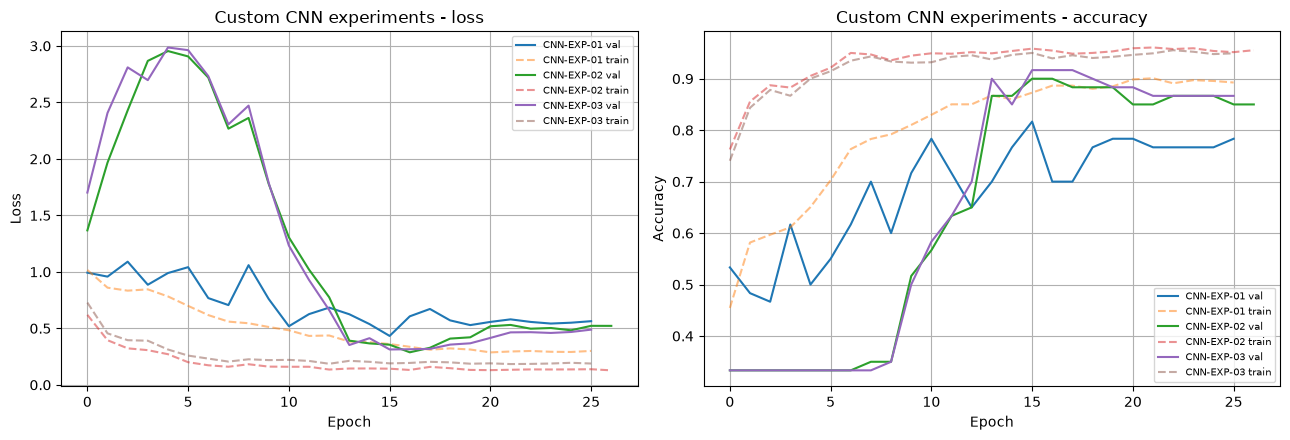

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for exp_id, h in experiment_histories.items():
    axes[0].plot(h["val_loss"], label=f"{exp_id} val"); axes[0].plot(h["loss"], "--", alpha=0.5, label=f"{exp_id} train")
    axes[1].plot(h["val_accuracy"], label=f"{exp_id} val"); axes[1].plot(h["accuracy"], "--", alpha=0.5, label=f"{exp_id} train")
axes[0].set(title="Custom CNN experiments - loss", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Custom CNN experiments - accuracy", xlabel="Epoch", ylabel="Accuracy")
for a in axes: a.grid(True); a.legend(fontsize=7)
plt.tight_layout(); plt.savefig(RESULTS_DIR / "customcnn_experiments_curves.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation – experiment curves.**
* **CNN-EXP-01 (plan baseline, no BatchNorm, 110k parameters)** learns slowly and steadily. Its best validation loss is 0.433 (validation accuracy 0.817) at epoch 16. Training accuracy at that point is only 0.873, so this shallower network **underfits**: its capacity and receptive field are too small for lesion patterns in 224×224 inputs.
* **CNN-EXP-02 and EXP-03 (4 blocks + BatchNorm, 391k parameters)** show a characteristic pattern. Training accuracy exceeds 0.85 after two epochs, but **validation loss rises to about 3.0 and validation accuracy stays at chance level (0.33–0.35, essentially one predicted class) for the first 9 epochs**. Then validation loss drops sharply, and both reach their best at epochs 16–17. The early spike comes from BatchNorm's moving mean and variance lagging behind rapidly changing weights at lr = 1e-3. Once ReduceLROnPlateau lowers the learning rate, the statistics stabilise. This is exactly the phase that the patience-6 callback in Run 1 cut off.
* **EXP-03 (dropout 0.5 + L2 1e-4) did not beat EXP-02** (best validation loss 0.313 vs 0.288). Its training and validation curves are almost the same, so extra regularisation brought no benefit. The limiting factor is not classic overfitting.

## 6. Select the final configuration (validation evidence only)

In [7]:
ranked = experiment_df.sort_values(["best_val_loss", "val_accuracy_at_best"], ascending=[True, False])
BEST_ID = ranked.iloc[0]["experiment_id"]
BEST_CONFIG = EXPERIMENTS[BEST_ID]
final_model = experiment_models[BEST_ID]
final_history = experiment_histories[BEST_ID]
best_record = ranked.iloc[0].to_dict()
print("Selected:", BEST_ID, BEST_CONFIG)
ranked[["experiment_id", "total_params", "best_epoch", "best_val_loss", "val_accuracy_at_best",
        "train_accuracy_at_best", "training_time_seconds"]]

Selected: CNN-EXP-02 {'filters': (32, 64, 128, 256), 'batch_norm': True, 'dropout': 0.3, 'l2': 0.0, 'dense_units': 0}


,experiment_id,total_params,best_epoch,best_val_loss,val_accuracy_at_best,train_accuracy_at_best,training_time_seconds
1,CNN-EXP-02,390627,17,0.288045,0.900000,0.954614,1471.562908
2,CNN-EXP-03,390627,16,0.313204,0.916667,0.950076,1478.090122
0,CNN-EXP-01,110147,16,0.433041,0.816667,0.872920,592.090590


**Selection.** **CNN-EXP-02** has the lowest validation loss (0.288, validation accuracy 0.900) and is selected, following the rule fixed before training. EXP-03 is a close second. The difference of 0.025 in validation loss is within the noise expected from 60 validation images, so the report should describe the two as statistically indistinguishable. EXP-02 is preferred as the simpler configuration (no L2).

Model: "CNN_EXP_02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169,963 (4.46 MB)

 Trainable params: 389,667 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 779,336 (2.97 MB)

Total params: 390627 | trainable: 389667 | non-trainable: 960


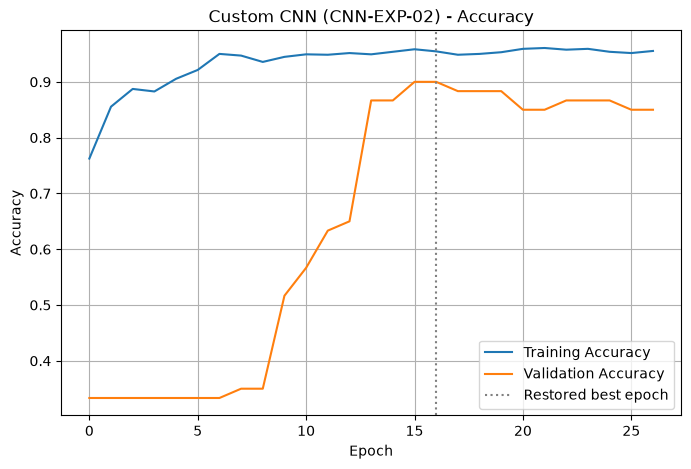

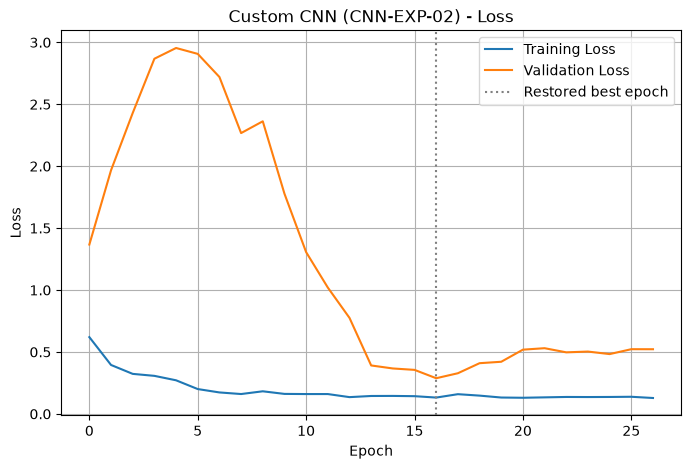

In [8]:
final_model.summary()
trainable_params = int(sum(np.prod(w.shape) for w in final_model.trainable_weights))
non_trainable_params = int(sum(np.prod(w.shape) for w in final_model.non_trainable_weights))
print("Total params:", final_model.count_params(), "| trainable:", trainable_params, "| non-trainable:", non_trainable_params)

for metric, label in [("accuracy", "Accuracy"), ("loss", "Loss")]:
    plt.figure(figsize=(8, 5))
    plt.plot(final_history[metric], label=f"Training {label}")
    plt.plot(final_history[f"val_{metric}"], label=f"Validation {label}")
    plt.axvline(best_record["best_epoch"] - 1, color="grey", ls=":", label="Restored best epoch")
    plt.title(f"Custom CNN ({BEST_ID}) - {label}"); plt.xlabel("Epoch"); plt.ylabel(label); plt.legend(); plt.grid(True)
    plt.savefig(RESULTS_DIR / f"customcnn_{metric}.png", dpi=300, bbox_inches="tight"); plt.show()

pd.DataFrame(final_history).rename_axis("epoch").to_csv(RESULTS_DIR / "customcnn_training_history.csv")

## 7. Generalisation check before touching the test set
Accuracy on the **un-augmented** training set vs the validation set. A large gap would indicate overfitting.

In [9]:
train_loss_clean, train_acc_clean = final_model.evaluate(train_eval_pipeline, verbose=0)
val_loss_final, val_acc_final = final_model.evaluate(val_pipeline, verbose=0)
print(f"Train (clean): loss={train_loss_clean:.4f} acc={train_acc_clean:.4f}")
print(f"Validation   : loss={val_loss_final:.4f} acc={val_acc_final:.4f}")

Train (clean): loss=0.1647 acc=0.9402
Validation   : loss=0.2880 acc=0.9000


**Interpretation – generalisation gap.** Clean training accuracy is 0.940 and validation accuracy 0.900, a gap of about 4 percentage points. The network fits the training data well but not perfectly, so there is **mild overfitting at most**. Augmentation, BatchNorm, global average pooling and early stopping keep a from-scratch network with 391k parameters from memorising 1,322 images.

## 8. Final test evaluation (configuration frozen — test set used once)

In [10]:
test_true_labels = np.array([int(y) for _, y in test_raw])
test_probabilities = final_model.predict(test_pipeline, verbose=0)
test_predictions = test_probabilities.argmax(axis=1)

test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(test_true_labels, test_predictions, average="weighted", zero_division=0)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(test_true_labels, test_predictions, average="macro", zero_division=0)
test_roc_auc = roc_auc_score(label_binarize(test_true_labels, classes=range(NUM_CLASSES)), test_probabilities,
                             multi_class="ovr", average="weighted")
test_loss = float(tf.keras.losses.sparse_categorical_crossentropy(test_true_labels, test_probabilities).numpy().mean())

print(classification_report(test_true_labels, test_predictions, target_names=CLASS_NAMES, digits=4))
print(f"Accuracy {test_accuracy:.4f} | weighted P {test_precision:.4f} R {test_recall:.4f} F1 {test_f1:.4f} | ROC-AUC {test_roc_auc:.4f} | test loss {test_loss:.4f}")
per_class_f1 = precision_recall_fscore_support(test_true_labels, test_predictions, average=None, zero_division=0)[2]

              precision    recall  f1-score   support

     Healthy     0.8393    0.9400    0.8868        50
     Powdery     0.9412    0.9600    0.9505        50
        Rust     0.9302    0.8000    0.8602        50

    accuracy                         0.9000       150
   macro avg     0.9036    0.9000    0.8992       150
weighted avg     0.9036    0.9000    0.8992       150

Accuracy 0.9000 | weighted P 0.9036 R 0.9000 F1 0.8992 | ROC-AUC 0.9819 | test loss 0.2733


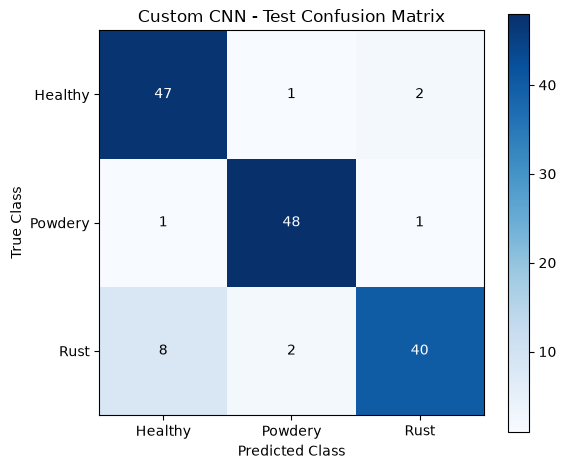

array([[47,  1,  2],
       [ 1, 48,  1],
       [ 8,  2, 40]])

In [11]:
cm = confusion_matrix(test_true_labels, test_predictions)
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(RESULTS_DIR / "customcnn_confusion_matrix.csv")

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Custom CNN - Test Confusion Matrix"); plt.xlabel("Predicted Class"); plt.ylabel("True Class")
plt.xticks(range(NUM_CLASSES), CLASS_NAMES); plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "customcnn_confusion_matrix.png", dpi=300, bbox_inches="tight"); plt.show()
cm

**Interpretation – test performance.**
* **Metrics:** test accuracy **0.900**, weighted F1 **0.899**, weighted ROC-AUC **0.982**. Test performance (0.900) equals validation performance (0.900) and is close to clean training accuracy (0.940), so the model **generalises consistently** to unseen images from the same source.
* **Powdery is the easiest class** (F1 0.95, 48/50 correct). The whitish coating changes global colour and texture, which the EDA showed to be strongly class-specific.
* **Rust is the hardest class** (recall 0.80), and **8 of its 10 errors are predicted as Healthy**. Healthy therefore has the lowest precision (0.84). The model's dominant failure is **missing rust rather than raising false alarms**, which is the costlier error in practice.
* **ROC-AUC (0.982) is much higher than accuracy.** The class probabilities rank images well even when the arg-max decision is wrong. Five of the eight Rust→Healthy errors have only 58–73% confidence, so a lower decision threshold for Rust would trade some precision for recall.

## 9. Error analysis

In [12]:
mis_idx = np.where(test_true_labels != test_predictions)[0]
error_df = pd.DataFrame([{
    "index": int(i), "filename": test_file_paths[i].name,
    "true_class": CLASS_NAMES[test_true_labels[i]], "predicted_class": CLASS_NAMES[test_predictions[i]],
    "confidence": float(test_probabilities[i].max()),
    "healthy_probability": float(test_probabilities[i][0]),
    "powdery_probability": float(test_probabilities[i][1]),
    "rust_probability": float(test_probabilities[i][2]),
} for i in mis_idx])
error_df.to_csv(RESULTS_DIR / "customcnn_error_analysis.csv", index=False)
print("Misclassified:", len(mis_idx), "of", len(test_true_labels))
display(error_df)
if len(error_df):
    display(error_df.groupby(["true_class", "predicted_class"]).size().reset_index(name="error_count"))

# Images misclassified by the other models as well (shared hard cases)
for other in ["mobilenetv2", "resnet50"]:
    p = RESULTS_DIR / f"{other}_error_analysis.csv"
    if p.exists():
        o = pd.read_csv(p)
        idx_col = "index" if "index" in o.columns else "sample_index"
        shared = sorted(set(o[idx_col]) & set(error_df.get("index", [])))
        print(f"Test indices also misclassified by {other}: {shared}")

Misclassified: 15 of 150


,index,filename,true_class,predicted_class,confidence,healthy_probability,powdery_probability,rust_probability
0,15,8e8470687be37378.jpg,Healthy,Rust,0.768735,0.225699,0.005566,0.768735
1,22,8eb0da4b65b0638f.jpg,Healthy,Powdery,0.630193,0.289257,0.630193,0.080550
2,28,8f137ee1d4f01a58.jpg,Healthy,Rust,0.591990,0.379814,0.028196,0.591990
3,55,81e5fcf446a9270b.jpg,Powdery,Rust,0.614026,0.338390,0.047584,0.614026
4,99,9ff7d2a548203c4b.jpg,Powdery,Healthy,0.911171,0.911171,0.000379,0.088450
5,105,83c2939deb266572.jpg,Rust,Healthy,0.710189,0.710189,0.019936,0.269875
6,108,84c3f037e53e66a1.jpg,Rust,Healthy,0.945278,0.945278,0.000007,0.054714
7,113,85e36e1b30afca61.jpg,Rust,Healthy,0.581388,0.581388,0.000004,0.418608
8,115,85f6618e5784b9a3.jpg,Rust,Healthy,0.837496,0.837496,0.000148,0.162356
9,128,89e926943ba5693b.jpg,Rust,Healthy,0.790313,0.790313,0.055669,0.154018


,true_class,predicted_class,error_count
0,Healthy,Powdery,1
1,Healthy,Rust,2
2,Powdery,Healthy,1
3,Powdery,Rust,1
4,Rust,Healthy,8
5,Rust,Powdery,2


Test indices also misclassified by mobilenetv2: [55, 99, 113, 128]
Test indices also misclassified by resnet50: [22, 55]


**Interpretation – error analysis (15/150 errors).**
* **Rust → Healthy (8 errors).** Almost all of these are leaves with **one small, isolated rust lesion** covering a tiny fraction of the frame (e.g. `83c2939deb266572`, `84c3f037e53e66a1`, `85f6618e5784b9a3`, `92ad52c79d278b31`, `93e896990cb365b5`). After 4000×2672 → 224×224 down-sampling a lesion shrinks to a few pixels. Global average pooling then averages that local evidence with a mostly healthy-looking leaf, so the "healthy leaf" features dominate. This is an architectural limitation of a small from-scratch network, and the error analysis ties it directly to an EDA finding.
* **Rust → Powdery (2 errors).** `95a921b75e401afe` (99% confident) has a large, **pale pinkish-white lesion** that resembles the whitish powdery coating in colour. `94c8b450b075eded` has a lesion at the leaf edge with pale speckling.
* **Healthy → Rust/Powdery (3 errors).** These involve **strong sun glare** (`8e8470687be37378`), a hand or finger in the frame (`8f137ee1d4f01a58`) and a blurred, whitish background (`8eb0da4b65b0638f`). These are background and illumination confounders rather than leaf symptoms.
* **Shared hard cases.** `81e5fcf446a9270b` (index 55) is also misclassified by both MobileNetV2 and ResNet50. `9ff7d2a548203c4b` (99), `85e36e1b30afca61` (113) and `89e926943ba5693b` (128) are also misclassified by MobileNetV2. Image 128 is one of the three blurriest images in the dataset (see the EDA notebook). These images are probably intrinsically ambiguous at 224×224, not failures specific to one architecture.

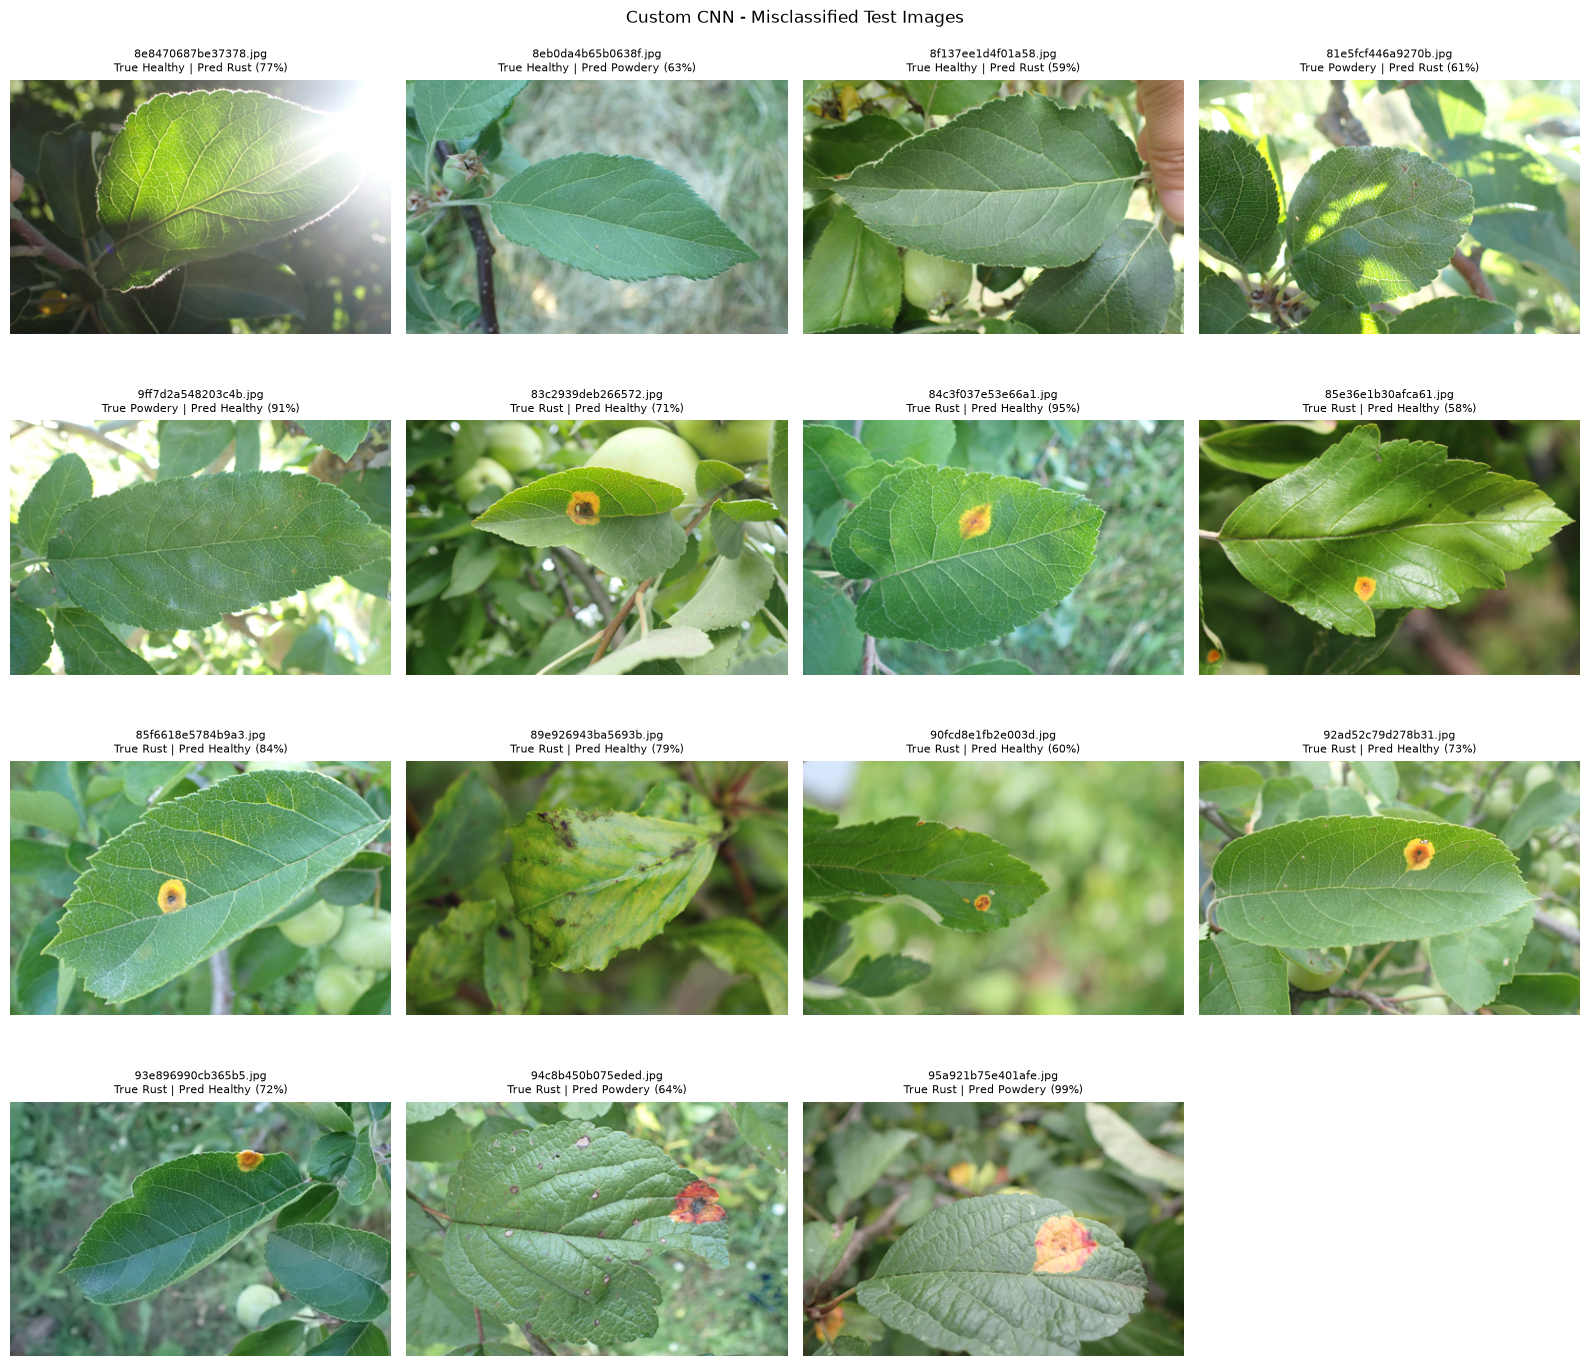

In [13]:
n = len(mis_idx)
if n:
    cols = min(4, n); rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4 * cols, 3.6 * rows))
    for k, i in enumerate(mis_idx):
        ax = plt.subplot(rows, cols, k + 1)
        ax.imshow(Image.open(test_file_paths[i]).convert("RGB").resize((400, 267)))
        ax.set_title(f"{test_file_paths[i].name}\nTrue {CLASS_NAMES[test_true_labels[i]]} | Pred {CLASS_NAMES[test_predictions[i]]} ({test_probabilities[i].max():.0%})", fontsize=8)
        ax.axis("off")
    plt.suptitle("Custom CNN - Misclassified Test Images"); plt.tight_layout()
    plt.savefig(RESULTS_DIR / "customcnn_misclassified.png", dpi=200, bbox_inches="tight"); plt.show()

### Grad-CAM: what is the network looking at?
Grad-CAM on the last convolutional block shows whether predictions are driven by lesion regions or by background/lighting cues. Shown for misclassified images and one correct example per class.

C:\Users\kodag\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


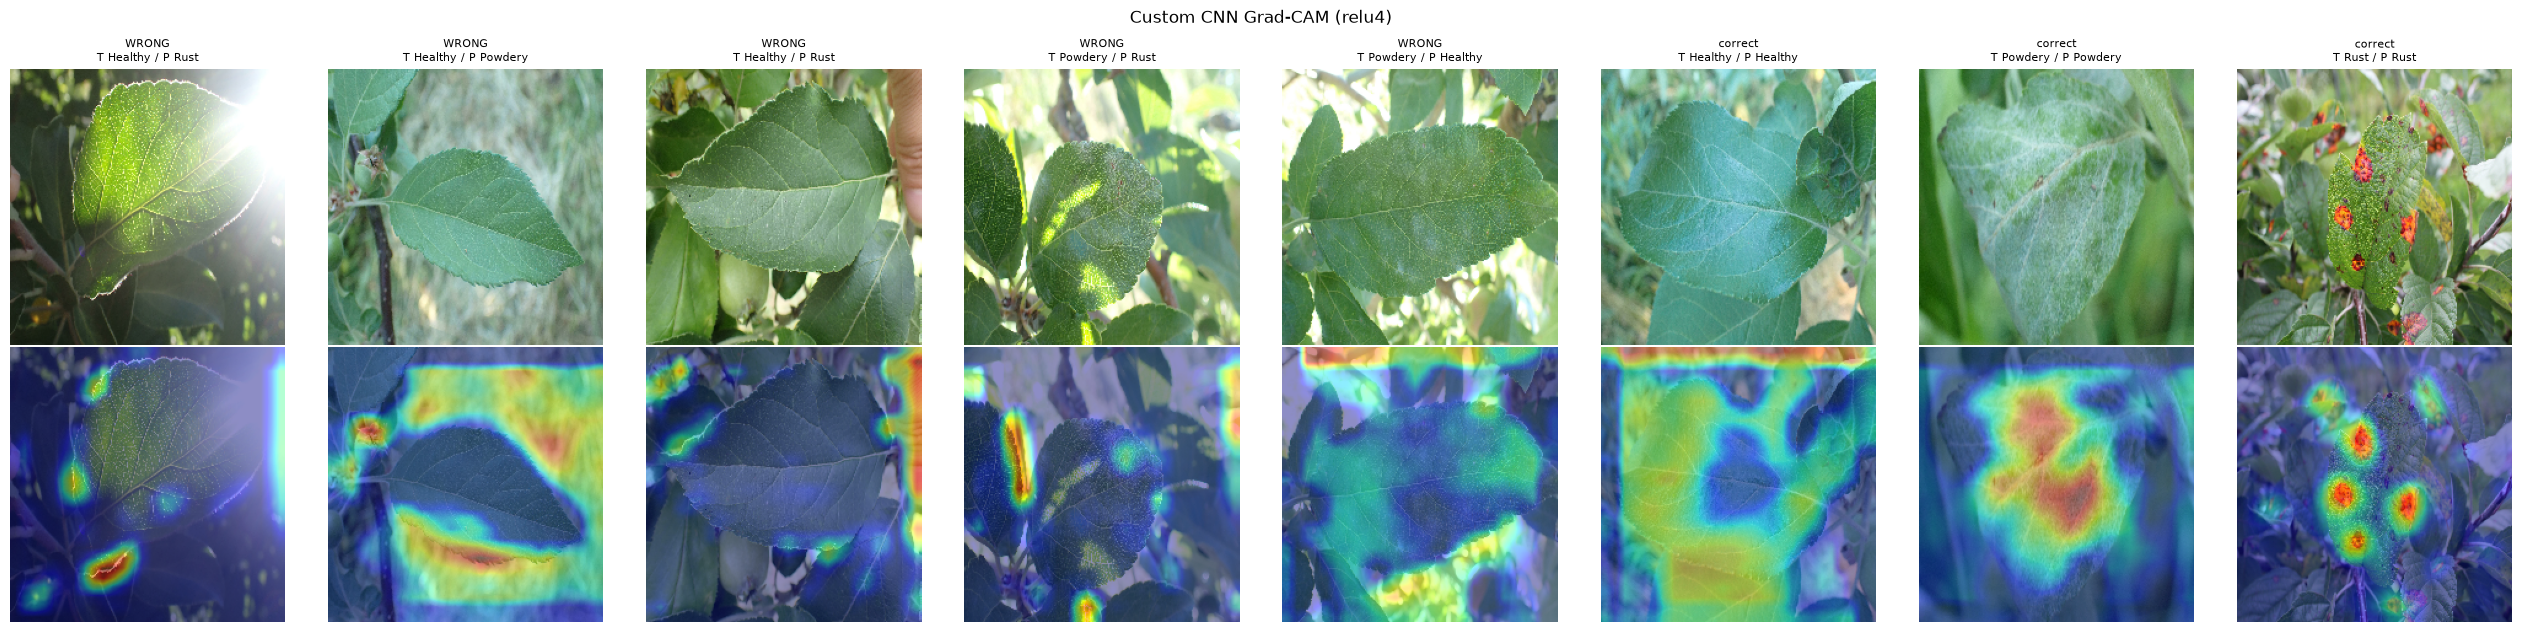

In [14]:
last_conv = [l.name for l in final_model.layers if l.name.startswith("relu")][-1]
grad_model = tf.keras.Model(final_model.inputs, [final_model.get_layer(last_conv).output, final_model.output])

def grad_cam(img):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img[None, ...])
        score = preds[:, tf.argmax(preds[0])]
    grads = tape.gradient(score, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.nn.relu(tf.reduce_sum(conv_out[0] * weights, axis=-1))
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return tf.image.resize(cam[..., None], IMG_SIZE).numpy()[..., 0]

test_images = np.stack([x.numpy() for x, _ in test_raw])
correct_examples = [int(np.where((test_true_labels == c) & (test_predictions == c))[0][0])
                    for c in range(NUM_CLASSES) if np.any((test_true_labels == c) & (test_predictions == c))]
show = list(mis_idx[:5]) + correct_examples
plt.figure(figsize=(3.2 * len(show), 6.4))
for k, i in enumerate(show):
    cam = grad_cam(test_images[i])
    plt.subplot(2, len(show), k + 1); plt.imshow(test_images[i].astype("uint8")); plt.axis("off")
    plt.title(f"{'WRONG' if i in mis_idx else 'correct'}\nT {CLASS_NAMES[test_true_labels[i]]} / P {CLASS_NAMES[test_predictions[i]]}", fontsize=8)
    plt.subplot(2, len(show), len(show) + k + 1); plt.imshow(test_images[i].astype("uint8")); plt.imshow(cam, cmap="jet", alpha=0.45); plt.axis("off")
plt.suptitle(f"Custom CNN Grad-CAM ({last_conv})"); plt.tight_layout()
plt.savefig(RESULTS_DIR / "customcnn_gradcam.png", dpi=200, bbox_inches="tight"); plt.show()

**Interpretation – Grad-CAM.**
* **For correctly classified Rust, the heat-map peaks on the individual orange lesions**, and for Powdery it covers the whitish coated area. The network has learned genuine symptom features.
* **For the misclassified examples, attention falls on the sun flare, on bright background regions or on a finger**, not on the leaf. This is evidence of **shortcut sensitivity to illumination and background**.
* **Even the correct Healthy example has its attention spread over the background.** "Healthy" is effectively learned as "absence of lesion/coating evidence anywhere in the frame".
* **Suggested improvements:** background-robust training (random crops or cut-out around the leaf, leaf segmentation), higher input resolution or tiled inference for small lesions, and more varied field images.

## 10. Efficiency: model size and inference latency

In [15]:
model_path = MODELS_DIR / "custom_cnn_best.keras"
final_model.save(model_path)
model_size_mb = model_path.stat().st_size / 1e6

sample = test_images[:1].astype("float32")
for _ in range(5): final_model(sample, training=False)          # warm-up
times = []
for i in range(50):
    t = time.perf_counter(); final_model(test_images[i:i + 1].astype("float32"), training=False); times.append(time.perf_counter() - t)
latency_ms = 1000 * float(np.median(times))
print(f"Saved model: {model_path} ({model_size_mb:.2f} MB)")
print(f"Median single-image CPU inference latency: {latency_ms:.1f} ms")

Saved model: ..\models\custom_cnn_best.keras (4.77 MB)
Median single-image CPU inference latency: 38.0 ms


**Interpretation – efficiency.** The model has 390,627 parameters and occupies **4.8 MB** on disk. Median single-image latency is **38 ms on a CPU**. For comparison, MobileNetV2 has 2.26M parameters and ResNet50 23.6M, so the Custom CNN is about 6× smaller than MobileNetV2 and about 60× smaller than ResNet50. Training took 24.5 min for 27 epochs (54.5 s/epoch) on a **16-thread AMD CPU without a GPU**. That is not directly comparable with the transfer-model timings, which were recorded on different hardware, so training times should only be compared within the same hardware.

## 11. Stability: repeat the frozen configuration with two more seeds
The selected configuration is retrained with seeds 123 and 2026 (no changes to hyperparameters). Test metrics for these runs are **reported only** — they are not used for any selection — so they measure run-to-run variance.

In [16]:
stability_rows = [{"seed": SEED, "best_epoch": best_record["best_epoch"], "best_val_loss": best_record["best_val_loss"],
                   "val_accuracy": best_record["val_accuracy_at_best"], "test_accuracy": test_accuracy,
                   "test_weighted_f1": test_f1, "test_roc_auc": test_roc_auc,
                   "training_time_seconds": best_record["training_time_seconds"]}]
for seed in [123, 2026]:
    print(f"\n========== {BEST_ID} seed {seed} ==========")
    m, h, rec = run_experiment(BEST_ID, BEST_CONFIG, seed=seed)
    probs = m.predict(test_pipeline, verbose=0); preds = probs.argmax(1)
    stability_rows.append({"seed": seed, "best_epoch": rec["best_epoch"], "best_val_loss": rec["best_val_loss"],
        "val_accuracy": rec["val_accuracy_at_best"], "test_accuracy": accuracy_score(test_true_labels, preds),
        "test_weighted_f1": precision_recall_fscore_support(test_true_labels, preds, average="weighted", zero_division=0)[2],
        "test_roc_auc": roc_auc_score(label_binarize(test_true_labels, classes=range(NUM_CLASSES)), probs, multi_class="ovr", average="weighted"),
        "training_time_seconds": rec["training_time_seconds"]})
stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(RESULTS_DIR / "customcnn_stability_runs.csv", index=False)
display(stability_df)
stability_df.drop(columns="seed").agg(["mean", "std"])


========== CNN-EXP-02 seed 123 ==========


Epoch 1/40


C:\Users\kodag\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


42/42 - 58s - 1s/step - accuracy: 0.7496 - loss: 0.6374 - val_accuracy: 0.3333 - val_loss: 1.3852 - learning_rate: 0.0010


Epoch 2/40


...

42/42 - 54s - 1s/step - accuracy: 0.9402 - loss: 0.1619 - val_accuracy: 0.9000 - val_loss: 0.3760 - learning_rate: 1.6000e-06


Epoch 25: early stopping


Restoring model weights from the end of the best epoch: 15.


,seed,best_epoch,best_val_loss,val_accuracy,test_accuracy,test_weighted_f1,test_roc_auc,training_time_seconds
0,42,17,0.288045,0.900000,0.900000,0.899168,0.981933,1471.562908
1,123,15,0.216481,0.933333,0.913333,0.912972,0.979200,1384.652670
2,2026,15,0.234296,0.916667,0.900000,0.899438,0.979600,1367.524443


,best_epoch,best_val_loss,val_accuracy,test_accuracy,test_weighted_f1,test_roc_auc,training_time_seconds
mean,15.666667,0.246274,0.916667,0.904444,0.903859,0.980244,1407.913340
std,1.154701,0.037255,0.016667,0.007698,0.007893,0.001476,55.783462


**Interpretation – stability.** Across seeds 42, 123 and 2026, test accuracy is **0.904 ± 0.008** (range 0.900–0.913) and ROC-AUC 0.980 ± 0.001. Best epochs were 15–17. With the corrected callbacks the from-scratch model is **stable**, in contrast to Run 1 (0.67–0.83 across the same seeds). The seed-42 model is the reported model; the other seeds only quantify variance.

## 12. Save results for the four-model comparison (Member 4)

In [17]:
final_results = pd.DataFrame([{
    "experiment_id": BEST_ID, "model": "Custom CNN", "pretrained_weights": "None (from scratch)",
    "test_samples": len(test_true_labels),
    "accuracy": test_accuracy, "weighted_precision": test_precision, "weighted_recall": test_recall,
    "weighted_f1": test_f1, "weighted_roc_auc": test_roc_auc,
    "macro_precision": macro_precision, "macro_recall": macro_recall, "macro_f1": macro_f1,
    "healthy_f1": per_class_f1[0], "powdery_f1": per_class_f1[1], "rust_f1": per_class_f1[2],
    "test_loss": test_loss,
    "train_accuracy_clean": train_acc_clean, "best_val_accuracy": best_record["val_accuracy_at_best"],
    "best_val_loss": best_record["best_val_loss"], "best_epoch": best_record["best_epoch"],
    "epochs_run": best_record["epochs_run"],
    "training_time_seconds": best_record["training_time_seconds"],
    "training_time_minutes": best_record["training_time_seconds"] / 60,
    "seconds_per_epoch": best_record["seconds_per_epoch"],
    "total_params": final_model.count_params(), "trainable_params": trainable_params,
    "model_size_mb": model_size_mb, "cpu_inference_latency_ms": latency_ms,
    "stability_test_accuracy_mean": stability_df["test_accuracy"].mean(),
    "stability_test_accuracy_std": stability_df["test_accuracy"].std(),
    "stability_runs": len(stability_df),
    "initial_learning_rate": INITIAL_LR, "optimizer": "Adam", "batch_size": BATCH_SIZE,
    "input_size": "224x224", "dropout": BEST_CONFIG["dropout"], "l2": BEST_CONFIG["l2"],
    "hardware": f"{ENVIRONMENT['processor']} ({ENVIRONMENT['logical_cpus']} logical CPUs), GPU={ENVIRONMENT['gpu_used']}",
}])
final_results.to_csv(RESULTS_DIR / "customcnn_final_results.csv", index=False)
experiment_df.to_csv(RESULTS_DIR / "customcnn_experiment_comparison.csv", index=False)

config = {
    "model": "Custom CNN", "selected_experiment": BEST_ID, "architecture": {k: (list(v) if isinstance(v, tuple) else v) for k, v in BEST_CONFIG.items()},
    "image_size": "224x224", "batch_size": BATCH_SIZE, "class_names": CLASS_NAMES, "seed": SEED,
    "stability_seeds": [42, 123, 2026],
    "augmentation": {"enabled_for_training": True, "enabled_for_validation": False, "enabled_for_test": False,
                      "horizontal_flip": True, "rotation_factor": 0.05, "translation_factor": 0.05, "zoom_factor": 0.10},
    "model_specific_preprocessing": {"function": "Rescaling(1/255) inside the model", "output_range": "0 to 1"},
    "optimizer": {"name": "Adam", "initial_learning_rate": INITIAL_LR},
    "callbacks": {"early_stopping": {"monitor": "val_loss", "patience": EARLY_STOP_PATIENCE, "restore_best_weights": True},
                  "reduce_lr_on_plateau": {"monitor": "val_loss", "factor": 0.2, "patience": LR_PATIENCE, "min_lr": 1e-6}},
    "max_epochs": MAX_EPOCHS, "selection_rule": "lowest validation loss (validation accuracy tie-break)",
    "environment": ENVIRONMENT,
}
with open(RESULTS_DIR / "customcnn_config.json", "w") as f:
    json.dump(config, f, indent=4, default=str)
final_results.T

,0
experiment_id,CNN-EXP-02
model,Custom CNN
pretrained_weights,None (from scratch)
test_samples,150
accuracy,0.9
weighted_precision,0.903565
weighted_recall,0.9
weighted_f1,0.899168
weighted_roc_auc,0.981933
macro_precision,0.903565


## 13. Summary (for the four-model comparison)
| Item | Custom CNN (CNN-EXP-02) |
|---|---|
| Architecture | 4 × [Conv3×3 → BN → ReLU → MaxPool] (32-64-128-256) → GAP → Dropout 0.3 → Dense(3, softmax) |
| Parameters | 390,627 (389,667 trainable) |
| Pretrained weights | None (trained from scratch) |
| Test accuracy / weighted F1 / ROC-AUC | 0.900 / 0.899 / 0.982 |
| Per-class F1 (Healthy / Powdery / Rust) | 0.887 / 0.950 / 0.860 |
| Clean train / validation / test accuracy | 0.940 / 0.900 / 0.900 |
| Stability (3 seeds) | 0.904 ± 0.008 test accuracy |
| Training time | 24.5 min (27 epochs, CPU only) |
| Model size / CPU latency | 4.8 MB / 38 ms per image |
| Main weakness | Misses small, isolated rust lesions (Rust → Healthy); sensitive to glare and background |

**Takeaway.** Without any pretrained knowledge, a compact CNN reaches 90% test accuracy from 1,322 images with a small generalisation gap. It trails the fine-tuned transfer models (MobileNetV2 94.7%, ResNet50 98.0%) mainly on subtle rust cases, which quantifies the value of ImageNet features for fine, small-scale symptoms. Its advantage is size: about 6× fewer parameters than MobileNetV2 and 60× fewer than ResNet50.